## Prefix Feature Projections

### Check CUDA is Available

In [2]:
# check CUDA available
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")

CUDA available: True
CUDA device count: 2
Current device: 0
Device name: NVIDIA GeForce RTX 2080 Ti


### Import Necessary Libraries

In [4]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

import torchmetrics

from transformers import T5Tokenizer, T5ForConditionalGeneration

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from bert_score import score as bert_score
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

from model_projections import (
    FeatureProjector,
    MultitaskModelWithProjection,
    ProjectionExperimentDataset,
    create_experiment_pipeline,
    evaluate_with_sampling,
    train,
    train_and_validate_model_with_meteor_rouge,
    train_and_validate_model_with_meteor_stopping,
    METEOREarlyStopping,
    display_generated_texts,
    print_test_evaluation,
    compute_rougeL
)


### Set Random Seed for Reproducibility

In [5]:
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

### Import Dataset

In [6]:
mwr_df = pd.read_csv('mwr.csv')

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


### Extract Features

In [7]:
print(mwr_df.columns)

Index(['Examination ID', 'Conclusion', 'r:Th', 'Weight', 'Height',
       'Ambient temperature', 'r:AgeInYears', 'Mammary diameter', 'Cycle',
       'Day from the first day', 'Hormonal medications',
       'Cancer family history', 'Breast operations', 'Num of pregnancies',
       'R1 int', 'L1 int', 'R2 int', 'L2 int', 'R3 int', 'L3 int', 'R4 int',
       'L4 int', 'R5 int', 'L5 int', 'R6 int', 'L6 int', 'R7 int', 'L7 int',
       'R8 int', 'L8 int', 'R9 int', 'L9 int', 'T1 int', 'T2 int', 'R0 int',
       'L0 int', 'R1 sk', 'L1 sk', 'R2 sk', 'L2 sk', 'R3 sk', 'L3 sk', 'R4 sk',
       'L4 sk', 'R5 sk', 'L5 sk', 'R6 sk', 'L6 sk', 'R7 sk', 'L7 sk', 'R8 sk',
       'L8 sk', 'R9 sk', 'L9 sk', 'T1 sk', 'T2 sk', 'R0 sk', 'L0 sk',
       'Conclusion (Tr)', 'y_binary'],
      dtype='object')


In [8]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df.columns if col.endswith('int') or col.endswith('sk')]
mwr_df['features'] = mwr_df[feature_cols].values.tolist()

# Prepare labels and text targets (binary classification)
mwr_df['class_label'] = mwr_df['y_binary'].astype(int)
mwr_df['synthetic_description'] = mwr_df['Conclusion (Tr)']

### Split Data into Test and Train

In [9]:
# 70% training, 15% validation, 15% testing

# Stratified split on 'r:Th' column
train_df, temp_df = train_test_split(
    mwr_df, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df['r:Th']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['r:Th']
)

In [10]:
# check class distribution
print(mwr_df['class_label'].value_counts(normalize=True))
#print(train_df['synthetic_description'].value_counts())

class_label
1    0.758215
0    0.241785
Name: proportion, dtype: float64


## Prefix Projection + Full Text

### Initialise Model

In [11]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
    train_df, val_df, test_df,
    projection_mode='prefix',         
    projection_type='linear',         
    use_minimal_text=False,          
    batch_size=32,
    learning_rate=5e-5
)


EXPERIMENT: PREFIX projection + FULL text
Projection type: linear


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: prefix
  Projection type: linear
  Minimal text: False
  Feature projection: Yes


### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 18.7139
Classification loss: 0.7795
Generation loss: 1.8636
Weighted gen loss: 18.635980
Validation loss: 10.6826
Validation metrics:
  Accuracy     : 0.7470
  F1-Score     : 0.6763
  Sensitivity  : 0.9614
  Specificity  : 0.0753
  AUC-ROC      : 0.6658

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4223
  ✓ New best METEOR: 0.4223
  ROUGE-L F1   : 0.4157
  ✓ New best ROUGE-L F1: 0.4157
✓ New best accuracy: 0.7470
✓ New best F1: 0.6763
✓ New best AUC-ROC: 0.6658

Epoch 2/50
Training loss: 11.3431
Classification loss: 0.5613
Generation loss: 1.1287
Weighted gen loss: 11.287004
Validation loss: 9.3711
Validation metrics:
  Accuracy     : 0.7459
  F1-Score     : 0.7099
  Sensitivity  : 0.9170
  Specificity  : 0.2098
  AUC-ROC      : 0.7032

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples

Computing text metrics on 3624 samples...
  METEOR Score : 0.4123
  ROUGE-L F1   : 0.4134
✓ New best accuracy: 0.7732
✓ New best F1: 0.7696
✓ New best AUC-ROC: 0.7966

Epoch 17/50
Training loss: 7.2271
Classification loss: 0.4711
Generation loss: 0.7180
Weighted gen loss: 7.180021
Validation loss: 6.7488
Validation metrics:
  Accuracy     : 0.7544
  F1-Score     : 0.7602
  Sensitivity  : 0.8129
  Specificity  : 0.5713
  AUC-ROC      : 0.7944

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4095
  ROUGE-L F1   : 0.4109

Epoch 18/50
Training loss: 7.1474
Classification loss: 0.4688
Generation loss: 0.7101
Weighted gen loss: 7.100501
Validation loss: 6.8276
Validation metrics:
  Accuracy     : 0.7707
  F1-Score     : 0.7685
  Sensitivity  : 0.8573
  Specificity  : 0.4994
  AUC-ROC      : 0.7958

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL dataset (3624 sample

Computing text metrics on 3624 samples...
  METEOR Score : 0.4147
  ROUGE-L F1   : 0.4138
✓ New best accuracy: 0.7922
✓ New best F1: 0.7860
✓ New best AUC-ROC: 0.8155

Epoch 33/50
Training loss: 6.3441
Classification loss: 0.4436
Generation loss: 0.6300
Weighted gen loss: 6.299696
Validation loss: 6.0802
Validation metrics:
  Accuracy     : 0.7707
  F1-Score     : 0.7761
  Sensitivity  : 0.8238
  Specificity  : 0.6043
  AUC-ROC      : 0.8132

--- Text Evaluation (Epoch 33) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4108
  ROUGE-L F1   : 0.4116
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 6.3163
Classification loss: 0.4412
Generation loss: 0.6272
Weighted gen loss: 6.272223
Validation loss: 6.0239
Validation metrics:
  Accuracy     : 0.7839
  F1-Score     : 0.7845
  Sensitivity  : 0.8551
  Specificity  : 0.5610
  AUC-ROC      : 0.8204

--- Text Evaluation (Epoch 34) ---
Evaluati

Computing text metrics on 3624 samples...
  METEOR Score : 0.4107
  ROUGE-L F1   : 0.4114
✓ New best AUC-ROC: 0.8310

Epoch 50/50
Training loss: 5.8695
Classification loss: 0.4221
Generation loss: 0.5827
Weighted gen loss: 5.827266
Validation loss: 5.8252
Validation metrics:
  Accuracy     : 0.7779
  F1-Score     : 0.7824
  Sensitivity  : 0.8322
  Specificity  : 0.6078
  AUC-ROC      : 0.8252

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4109
  ROUGE-L F1   : 0.4115


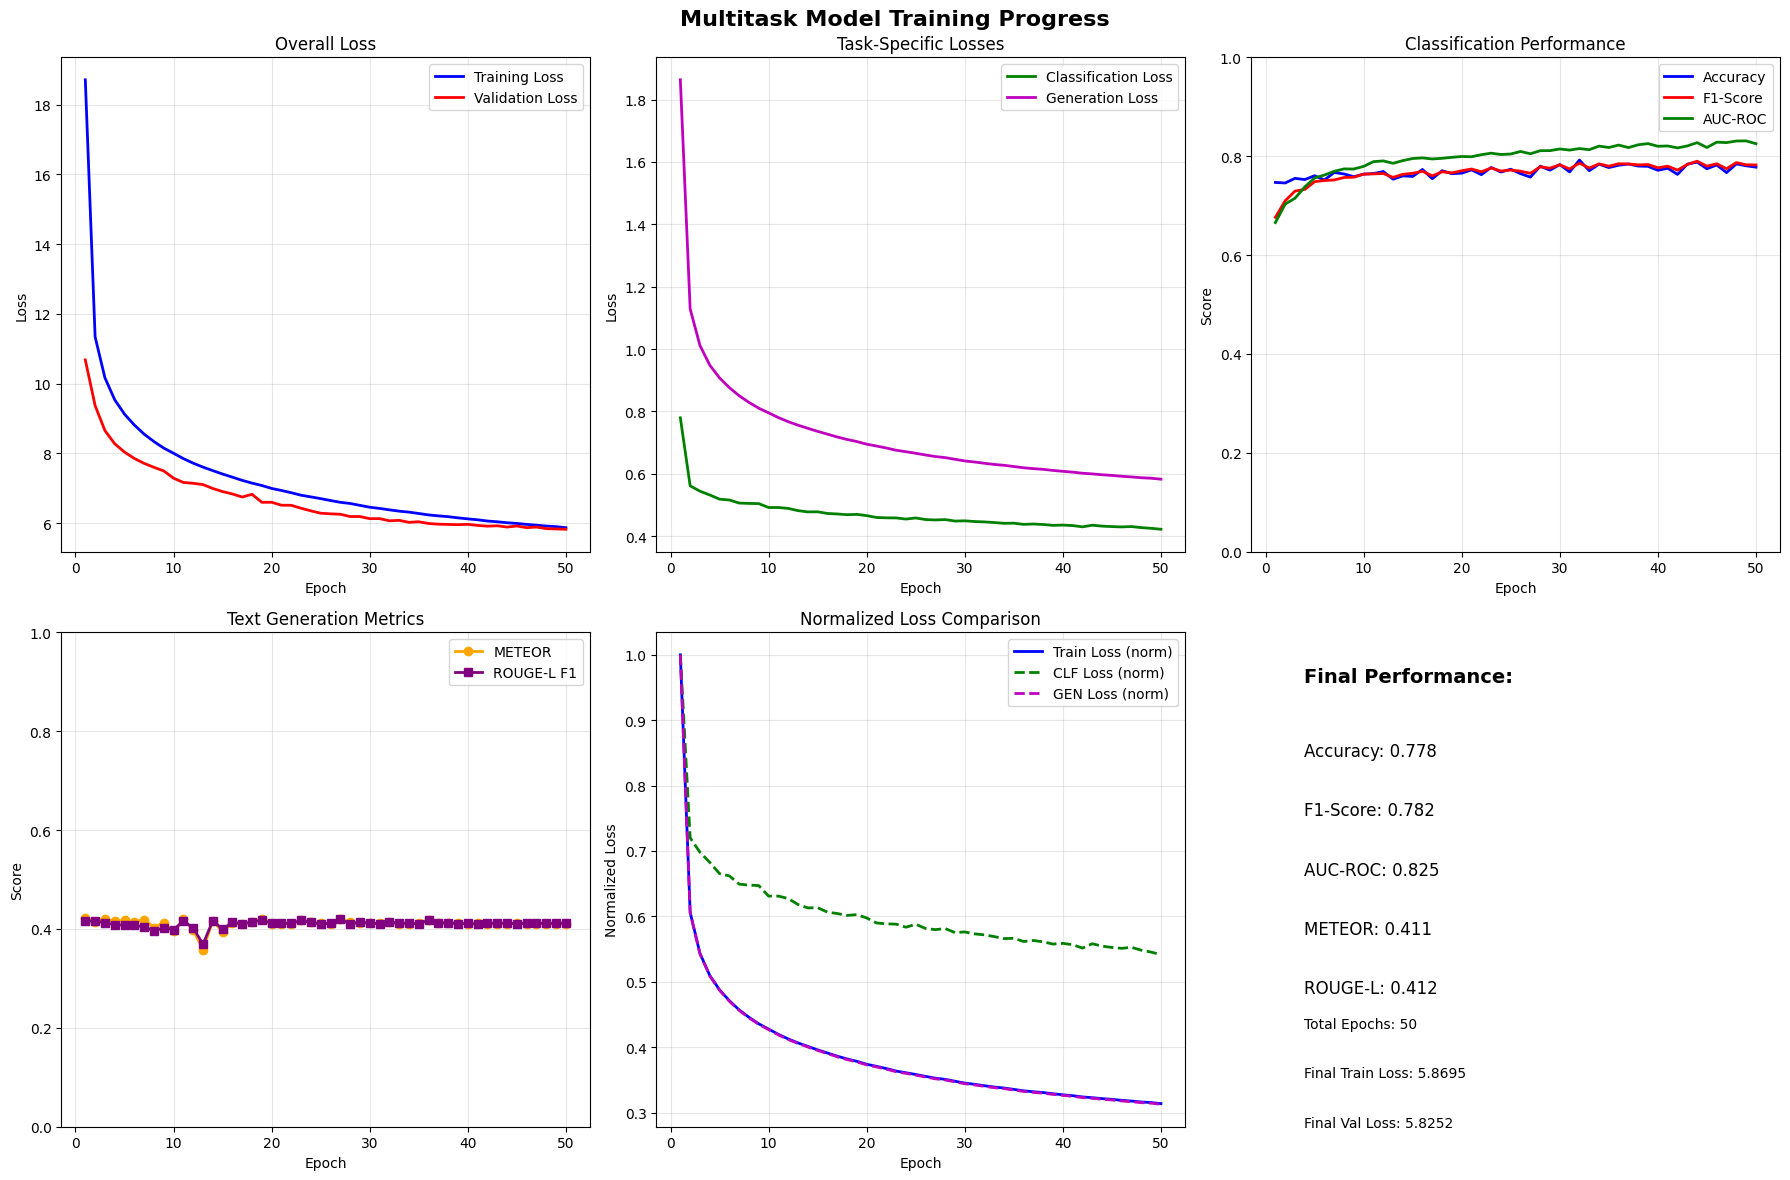


TRAINING SUMMARY
Best Accuracy: 0.7922
Best F1-Score: 0.7899
Best AUC-ROC: 0.8310
Best METEOR: 0.4223
Best ROUGE-L: 0.4192


In [12]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [13]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.7771
Classification metrics (all 3625 samples):
  Accuracy     : 0.7931
  F1-Score     : 0.7968
  Sensitivity  : 0.8454
  Specificity  : 0.6290
  AUC-ROC      : 0.8445

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4051
  METEOR       : 0.4053

Sample efficiency: 3625/3625 samples used for text metrics


In [14]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend the next check-up in 1 year (May 2015). During this period, we advise regular self-examinations. In case of noticeable, visible changes, discharge, or prolonged pain, please schedule an earlier
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend the next check-up in 1 year (May 2015). During this period, we advise regular self-examinations. In case of noticeable, visible changes, discharge, or prolonged pain, please schedule an earlier
Reference :

## Prefix Feature Projection + Minimal Text

### Initialise Model

In [11]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
    train_df, val_df, test_df,
    projection_mode='prefix',         
    projection_type='linear',         
    use_minimal_text=True,          
    batch_size=32,
    learning_rate=5e-5
)


EXPERIMENT: PREFIX projection + MINIMAL text
Projection type: linear


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: prefix
  Projection type: linear
  Minimal text: True
  Feature projection: Yes


### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 19.6348
Classification loss: 0.7541
Generation loss: 1.9559
Weighted gen loss: 19.559361
Validation loss: 10.7641
Validation metrics:
  Accuracy     : 0.7423
  F1-Score     : 0.7121
  Sensitivity  : 0.9043
  Specificity  : 0.2349
  AUC-ROC      : 0.6915

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4236
  ✓ New best METEOR: 0.4236
  ROUGE-L F1   : 0.4157
  ✓ New best ROUGE-L F1: 0.4157
✓ New best accuracy: 0.7423
✓ New best F1: 0.7121
✓ New best AUC-ROC: 0.6915

Epoch 2/50
Training loss: 11.5821
Classification loss: 0.5535
Generation loss: 1.1527
Weighted gen loss: 11.526723
Validation loss: 9.4106
Validation metrics:
  Accuracy     : 0.7431
  F1-Score     : 0.7316
  Sensitivity  : 0.8657
  Specificity  : 0.3592
  AUC-ROC      : 0.7169

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples

Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best accuracy: 0.7817
✓ New best F1: 0.7762
✓ New best AUC-ROC: 0.8028

Epoch 17/50
Training loss: 7.3960
Classification loss: 0.4629
Generation loss: 0.7350
Weighted gen loss: 7.349735
Validation loss: 6.8857
Validation metrics:
  Accuracy     : 0.7522
  F1-Score     : 0.7612
  Sensitivity  : 0.7943
  Specificity  : 0.6203
  AUC-ROC      : 0.8045

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best AUC-ROC: 0.8045

Epoch 18/50
Training loss: 7.3111
Classification loss: 0.4655
Generation loss: 0.7265
Weighted gen loss: 7.264528
Validation loss: 6.7577
Validation metrics:
  Accuracy     : 0.7740
  F1-Score     : 0.7737
  Sensitivity  : 0.8522
  Specificity  : 0.5291
  AUC-ROC      : 0.8064

--- Text Evaluation (Epoch 18) ---
Evaluating text generation o

Computing text metrics on 3624 samples...
  METEOR Score : 0.4223
  ROUGE-L F1   : 0.4142
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 6.4543
Classification loss: 0.4342
Generation loss: 0.6411
Weighted gen loss: 6.410847
Validation loss: 6.1045
Validation metrics:
  Accuracy     : 0.7743
  F1-Score     : 0.7762
  Sensitivity  : 0.8427
  Specificity  : 0.5599
  AUC-ROC      : 0.8221

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4223
  ROUGE-L F1   : 0.4142

Epoch 35/50
Training loss: 6.4332
Classification loss: 0.4356
Generation loss: 0.6390
Weighted gen loss: 6.389675
Validation loss: 6.1024
Validation metrics:
  Accuracy     : 0.7757
  F1-Score     : 0.7811
  Sensitivity  : 0.8264
  Specificity  : 0.6169
  AUC-ROC      : 0.8256

--- Text Evaluation (Epoch 35) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3

Validation loss: 5.8898
Validation metrics:
  Accuracy     : 0.7732
  F1-Score     : 0.7798
  Sensitivity  : 0.8183
  Specificity  : 0.6317
  AUC-ROC      : 0.8272

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4223
  ROUGE-L F1   : 0.4142


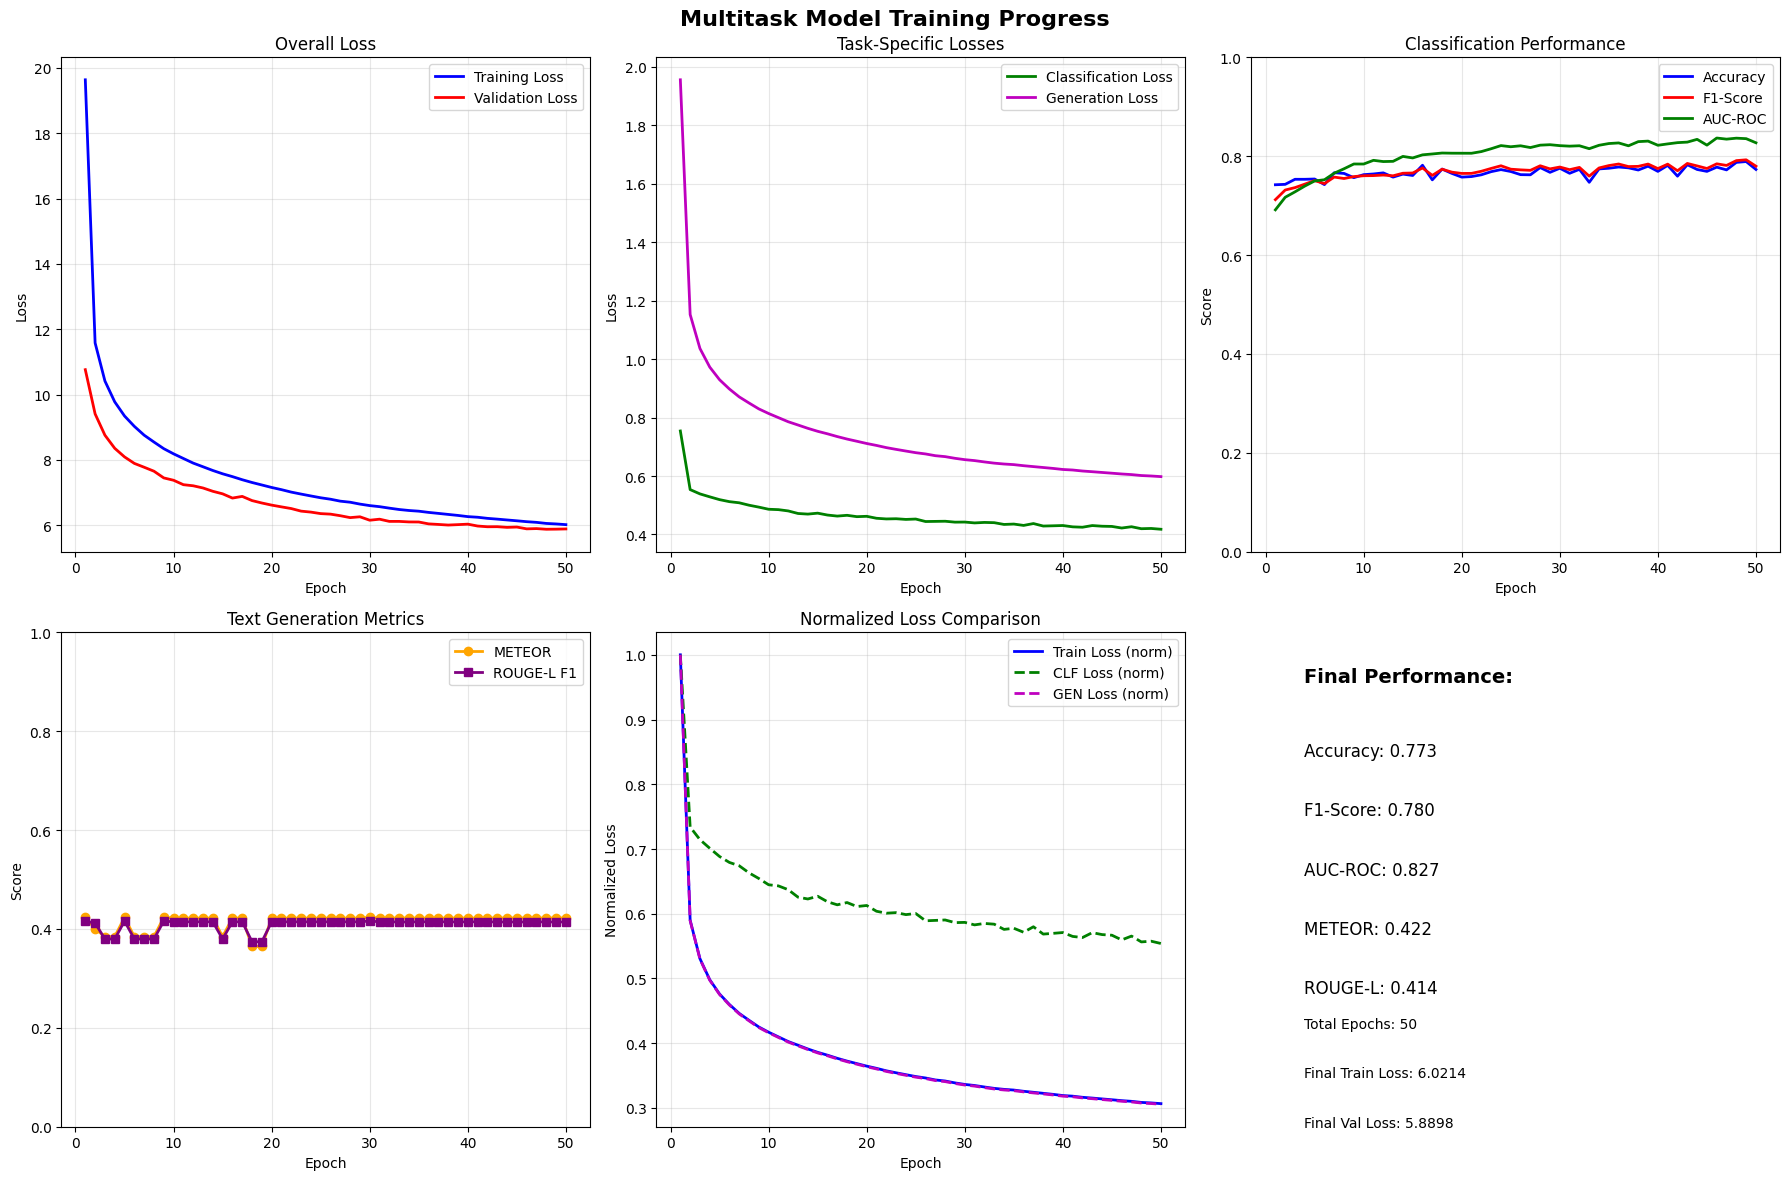


TRAINING SUMMARY
Best Accuracy: 0.7892
Best F1-Score: 0.7927
Best AUC-ROC: 0.8368
Best METEOR: 0.4236
Best ROUGE-L: 0.4160


In [12]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [13]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.8387
Classification metrics (all 3625 samples):
  Accuracy     : 0.8008
  F1-Score     : 0.8055
  Sensitivity  : 0.8439
  Specificity  : 0.6655
  AUC-ROC      : 0.8486

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4124
  METEOR       : 0.4210

Sample efficiency: 3625/3625 samples used for text metrics


In [14]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally elevated metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a specialist doctor and
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally elevated metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a s